In [15]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood

reload(dap)

np.set_printoptions(suppress=True)

In [16]:
uoep = {'mu': 0, 'sigma': 2.0} 
poep = {'mu': 0, 'sigma': 2.0} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}

DB: Starting cycle 0
DB: Starting cycle 20
DB: Starting cycle 40
DB: Starting cycle 60
DB: Starting cycle 80
DB: Starting cycle 100
DB: Starting cycle 120
DB: Starting cycle 140
DB: Starting cycle 160
DB: Starting cycle 180
DB: Starting cycle 200
DB: Starting cycle 220
DB: Starting cycle 240
DB: Starting cycle 260
DB: Starting cycle 280
DB: Starting cycle 300
DB: Starting cycle 320
DB: Starting cycle 340
DB: Starting cycle 360
DB: Starting cycle 380
DB: Starting cycle 400
(8000, 1)
[   0    1    2 ... 7997 7998 7999]
knn is: 800, number of samples = 8000
using median distance without 0s: 0.026329182583219035
0.026329182583219035
(8000, 1)
[   0    1    2 ... 7997 7998 7999]
knn is: 800, number of samples = 8000
using median distance without 0s: 0.025535260580978297
0.025535260580978297
CPU times: user 51 s, sys: 11.6 s, total: 1min 2s
Wall time: 12.5 s


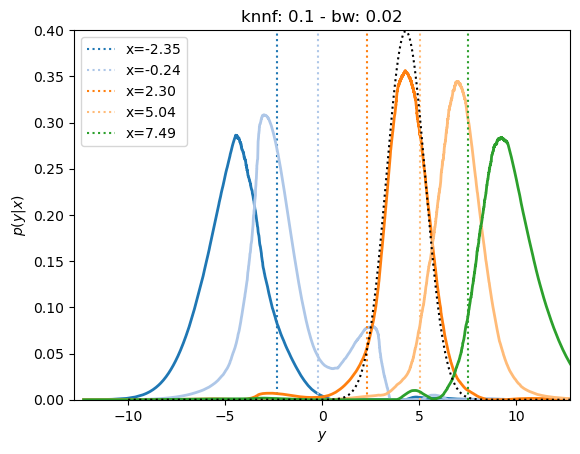

In [17]:
%%time
knns = [0.1]
bws = [0.02]
for knn in knns:
    for bw in bws:
        e_kecd_test = dap.Expt("test", {'expt_flag': 3,
                               'model_flag':1,
                               'localize':1,
                               'obf': 2,
                               'seed': 58,
                               'h_flag': 0,
                               'qc_flag': 0,
                               'used_obs_err': 1,
                               'prescribed_obs_err': 0,
                               'used_obs_err_params': uoep_sd,
                               'prescribed_obs_err_params': poep,
                               'save_keest_pab':1,
                               'Ne':80,
                               'T': 401,
                               'T_train': 400,
                                'nle_every': 50,
                               'knn_frac': knn,
                                'nle_type': 4,
                                'bw_dm': 'knn_adaptive',
                                'Neig': 50
                               })
        dap.runDA(e_kecd_test)
        fig, ax = plt.subplots()
        dap.plot_pab(e_kecd_test, plot_states=True, ax=ax)
        plot_val = np.quantile(e_kecd_test.x_train, 0.5)
        ax.plot(np.linspace(-10, 15, 2000), norm.pdf(np.linspace(-10,15,2000), loc=plot_val+2), linestyle='dotted', c='k')
        ax.set_ylim(0,0.4)
        ax.set_title(f'knnf: {knn} - bw: {bw}')
        plt.close()

23.5s originally
